# II. Khám phá dữ liệu

Phần này thực hiện phân tích chi tiết về bộ dữ liệu, bao gồm kiểm tra chất lượng dữ liệu, phân tích các biến số và phân loại, phát hiện outliers và missing values, cùng với việc khám phá mối quan hệ giữa các biến.

## 2.1 Import Libraries và Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
df = pd.read_csv('../dataset/track_data_final.csv')
print(f"Dataset loaded: {len(df):,} rows")

Dataset loaded: 8,778 rows


## 2.2 Tổng quan về Dataset (Dataset Overview)

### Thông tin cơ bản (Basic Information)

In [ ]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Rows: 8,778
Columns: 15
Memory: 5.26 MB


Mỗi hàng đại diện cho một bài hát (track) trên Spotify.

### Tính toàn vẹn của dữ liệu

In [ ]:
duplicated_by_id = df.duplicated(subset=['track_id']).sum()
duplicated_all = df.duplicated().sum()
empty_rows = df.isnull().all(axis=1).sum()

print(f"Duplicated by track_id: {duplicated_by_id:,}")
print(f"Duplicated rows (all columns): {duplicated_all:,}")
print(f"Empty rows: {empty_rows:,}")

Duplicated by track_id: 0
Duplicated rows (all columns): 0
Empty rows: 0


Không có dữ liệu trùng lặp, không có dòng trống. Tất cả các `track_id` là duy nhất nên không cần xóa bản ghi trùng lặp (duplicate).

### Danh sách các cột

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8778 entries, 0 to 8777
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8778 non-null   object 
 1   track_name          8776 non-null   object 
 2   track_number        8778 non-null   int64  
 3   track_popularity    8778 non-null   int64  
 4   track_duration_ms   8778 non-null   int64  
 5   explicit            8778 non-null   bool   
 6   artist_name         8774 non-null   object 
 7   artist_popularity   8774 non-null   float64
 8   artist_followers    8774 non-null   float64
 9   artist_genres       8774 non-null   object 
 10  album_id            8778 non-null   object 
 11  album_name          8776 non-null   object 
 12  album_release_date  8778 non-null   object 
 13  album_total_tracks  8778 non-null   int64  
 14  album_type          8778 non-null   object 
dtypes: bool(1), float64(2), int64(4), object(8)
memory usag

Ý nghĩa các cột:

Thông tin bài hát (Track Information):
- `track_id`: Mã định danh duy nhất của bài hát
- `track_name`: Tên bài hát
- `track_number`: Vị trí trong album
- `track_popularity`: Độ phổ biến (0-100)
- `track_duration_ms`: Thời lượng (milliseconds)
- `explicit`: Có nội dung nhạy cảm không

Thông tin nghệ sĩ (Artist Information):
- `artist_name`: Tên nghệ sĩ
- `artist_popularity`: Độ phổ biến nghệ sĩ (0-100)
- `artist_followers`: Số người theo dõi
- `artist_genres`: Thể loại âm nhạc

Thông tin Album (Album Information):
- `album_id`: Mã định danh album
- `album_name`: Tên album
- `album_release_date`: Ngày phát hành
- `album_total_tracks`: Tổng số bài
- `album_type`: Loại (album/single/compilation)

Các cột quan trọng cho phân tích: `track_popularity`, `artist_popularity`, `artist_followers`, `artist_genres`, `album_release_date`, `track_duration_ms`.

Không có cột cần bỏ vì tất cả đều có giá trị phân tích.

### Các kiểu dữ liệu (Data Types)

In [ ]:
df.dtypes

track_id               object
track_name             object
track_number            int64
track_popularity        int64
track_duration_ms       int64
explicit                 bool
artist_name            object
artist_popularity     float64
artist_followers      float64
artist_genres          object
album_id               object
album_name             object
album_release_date     object
album_total_tracks      int64
album_type             object
dtype: object

Cần chuyển đổi một số cột:
- `artist_popularity` và `artist_followers`: float64 -> int64 (sau khi xử lý missing)
- `album_release_date`: object -> datetime
- `track_duration_ms`: tạo thêm cột `track_duration_min` để dễ đọc hơn

In [ ]:
df['artist_popularity'] = df['artist_popularity'].fillna(0).astype('int64')
df['artist_followers'] = df['artist_followers'].fillna(0).astype('int64')
df['album_release_date'] = pd.to_datetime(df['album_release_date'], errors='coerce')
df['year'] = df['album_release_date'].dt.year
df['track_duration_min'] = df['track_duration_ms'] / 60000.0

## 2.3 Phân tích các cột Numerical

In [ ]:
numerical_cols = ['track_popularity', 'artist_popularity', 'artist_followers', 
                  'track_duration_min', 'album_total_tracks', 'year']

df[numerical_cols].describe()

,track_popularity,artist_popularity,artist_followers,track_duration_min,album_total_tracks,year
count,8778.00,8778.00,8778.00,8778.00,8778.00,8577.00
mean,52.23,69.92,24343767.66,3.50,13.78,2015.44
std,24.08,19.59,38132537.98,1.06,11.80,9.47
min,0.00,0.00,0.00,0.00,1.00,1952.00
25%,39.00,60.00,512702.50,2.90,6.00,2012.00
50%,58.00,74.00,6223889.50,3.45,13.00,2018.00
75%,71.00,84.00,30550549.00,3.99,17.00,2022.00
max,100.00,100.00,145542136.00,13.52,181.00,2025.00


### Phân phối & Xu hướng tập trung

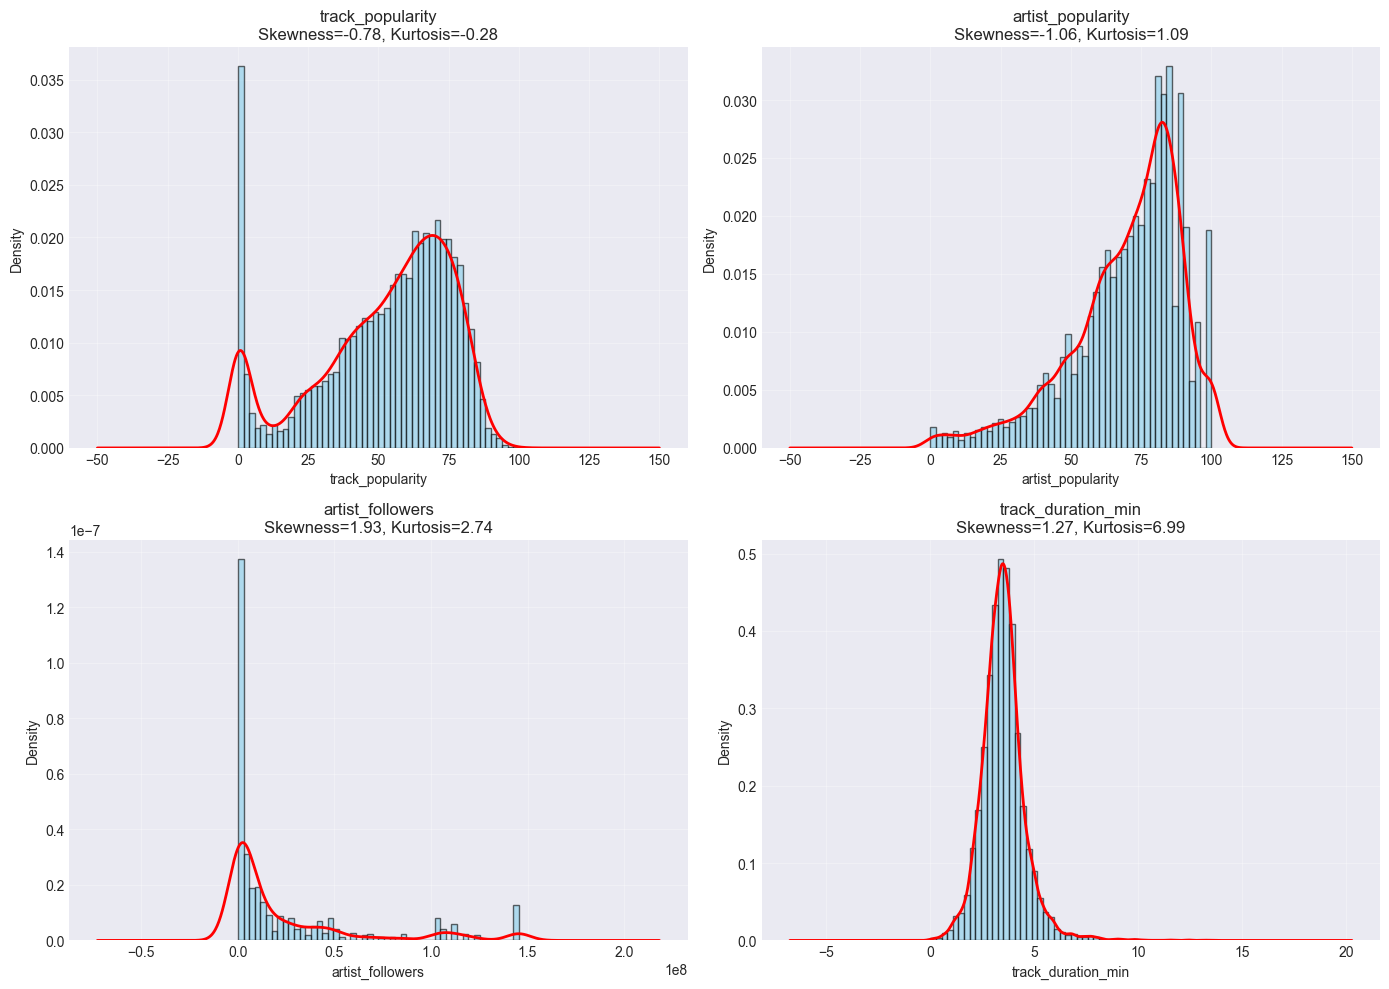

In [ ]:
key_cols = ['track_popularity', 'artist_popularity', 'artist_followers', 'track_duration_min']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(key_cols):
    data = df[col].dropna()
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)
    
    axes[i].hist(data, bins=50, edgecolor='black', alpha=0.6, density=True, color='skyblue')
    data.plot(kind='kde', ax=axes[i], color='red', linewidth=2)
    axes[i].set_title(f'{col}\nSkewness={skew:.2f}, Kurtosis={kurt:.2f}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

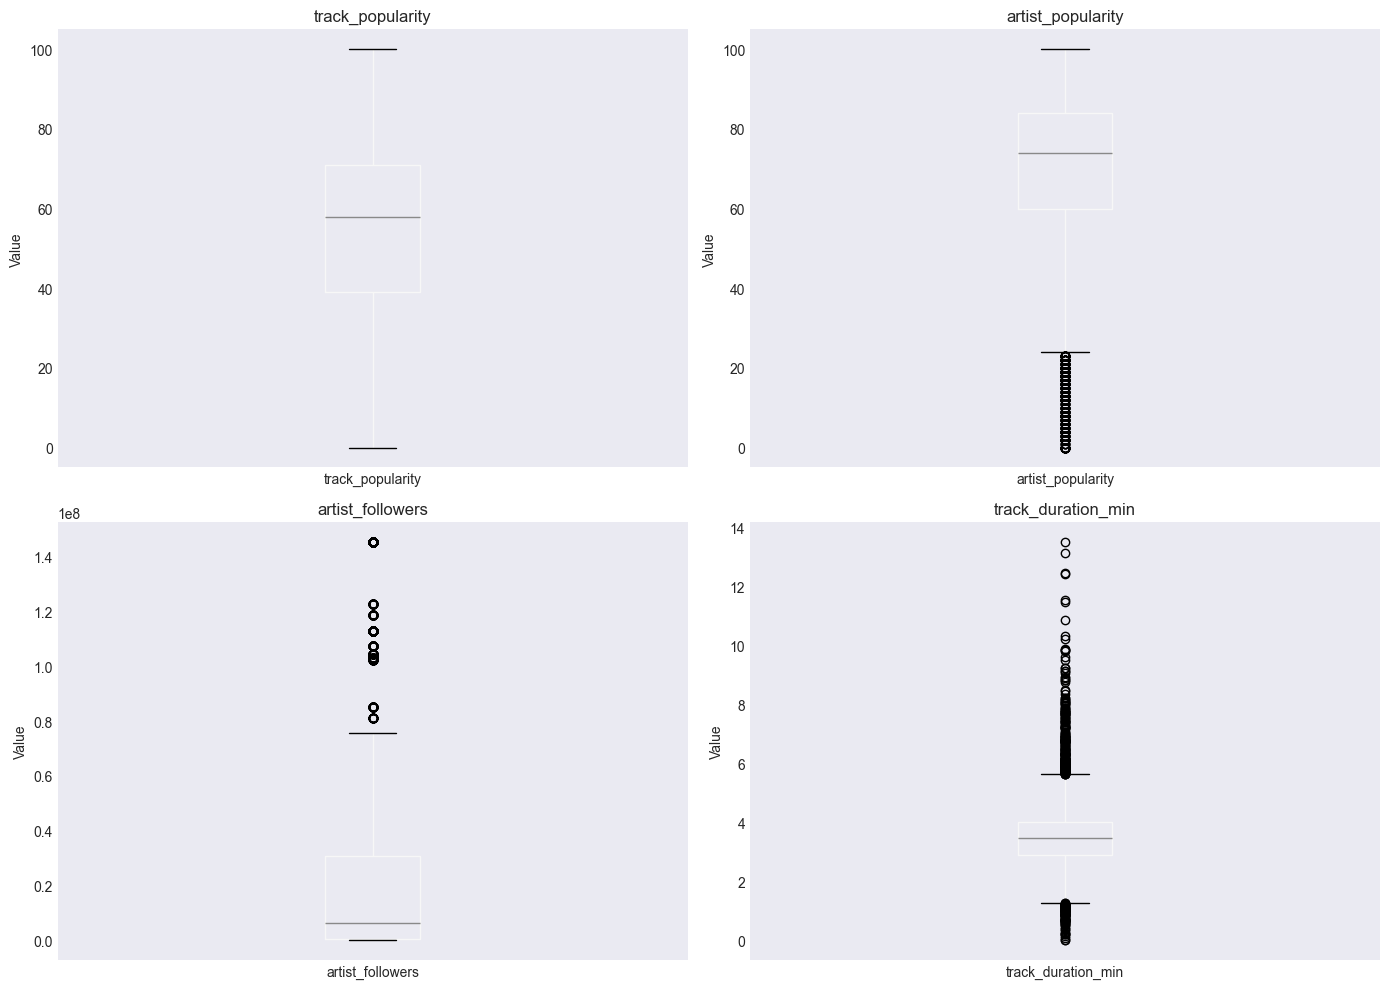

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(key_cols):
    df.boxplot(column=col, ax=axes[i], grid=False)
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

Dựa vào biểu đồ histogram, KDE plots và các chỉ số Skewness & Kurtosis ở trên, chúng ta có thể xác định hình dạng phân phối của các cột số:

1. **`track_popularity`**:
   - Phân phối lệch trái
   - Có xu hướng bimodal nhẹ

2. **`artist_popularity`**: 
   - Phân phối lệch trái mạnh
   - Cũng có bimodal nhẹ

3. **`artist_followers`**: 
   - Phân phối lệch phải cực mạnh


4. **`track_duration_min`**: 
   - Phân phối lệch phải

### Phạm vi & Giá trị ngoại lai

In [ ]:
for col in key_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = outliers / len(df) * 100
    
    print(f"{col}: {outliers:,} outliers ({pct:.2f}%)")

track_popularity: 0 outliers (0.00%)
artist_popularity: 289 outliers (3.29%)
artist_followers: 999 outliers (11.38%)
track_duration_min: 377 outliers (4.29%)


Outliers trong `artist_followers` là các giá trị cực đoan trong thực tế - các siêu sao với hàng triệu followers. Các outliers khác cũng là giá trị hợp lý, không phải lỗi dữ liệu (data errors).

### Chất lượng dữ liệu

KIỂM TRA PHÂN PHỐI CHO TỪNG NHÓM ALBUM_TYPE

Album (n=6022):
  Mean: 55.53, Median: 61.00
  Skewness: -0.967, Kurtosis: 0.228
  Anderson-Darling: statistic=163.0546
    Critical values: [0.576 0.656 0.786 0.917 1.091]
    → KHÔNG tuân theo phân phối chuẩn (at 5% significance)

Single (n=2248):
  Mean: 46.05, Median: 51.00
  Skewness: -0.466, Kurtosis: -0.906
  Shapiro-Wilk: W=0.9314, p-value=5.9261e-31
    → KHÔNG tuân theo phân phối chuẩn
  Anderson-Darling: statistic=45.3302
    Critical values: [0.575 0.655 0.786 0.916 1.09 ]
    → KHÔNG tuân theo phân phối chuẩn (at 5% significance)

Compilation (n=508):
  Mean: 40.51, Median: 44.00
  Skewness: -0.494, Kurtosis: -0.423
  Shapiro-Wilk: W=0.9389, p-value=1.3895e-13
    → KHÔNG tuân theo phân phối chuẩn
  Anderson-Darling: statistic=9.4571
    Critical values: [0.572 0.651 0.781 0.911 1.084]
    → KHÔNG tuân theo phân phối chuẩn (at 5% significance)


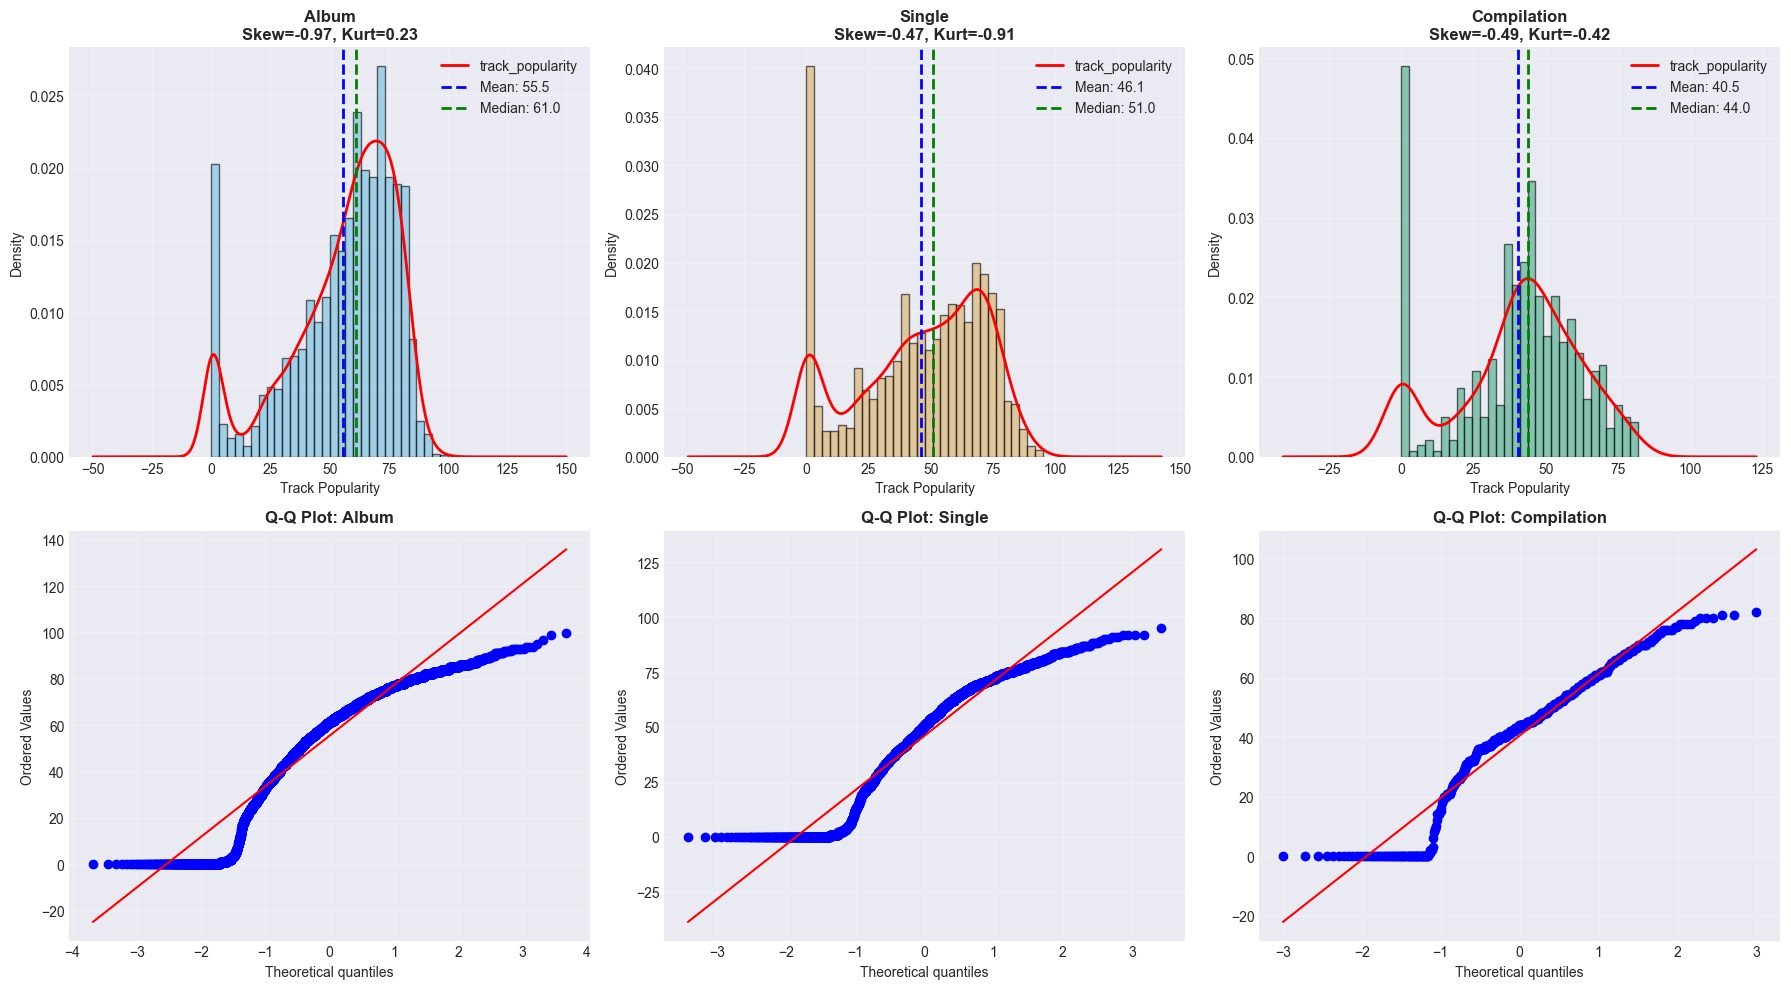


KẾT LUẬN VỀ PHÂN PHỐI:
Tất cả 3 nhóm đều KHÔNG tuân theo phân phối chuẩn (non-normal distribution).
→ NÊN SỬ DỤNG: Kruskal-Wallis test (non-parametric)
→ CÓ THỂ THAM KHẢO: ANOVA (robust to non-normality với sample size lớn)


In [ ]:
# Kiểm tra phân phối cho từng nhóm album_type
from scipy.stats import shapiro, anderson, normaltest

# Chuẩn bị dữ liệu  
group_album = df[df['album_type'] == 'album']['track_popularity'].dropna()
group_single = df[df['album_type'] == 'single']['track_popularity'].dropna()
group_compilation = df[df['album_type'] == 'compilation']['track_popularity'].dropna()

print("="*80)
print("KIỂM TRA PHÂN PHỐI CHO TỪNG NHÓM ALBUM_TYPE")
print("="*80)

groups = {
    'Album': group_album,
    'Single': group_single,
    'Compilation': group_compilation
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (name, data) in enumerate(groups.items()):
    print(f"\n{name} (n={len(data)}):")
    print(f"  Mean: {data.mean():.2f}, Median: {data.median():.2f}")
    print(f"  Skewness: {data.skew():.3f}, Kurtosis: {data.kurtosis():.3f}")
    
    # Shapiro-Wilk test (n < 5000)
    if len(data) <= 5000:
        stat_sw, p_sw = shapiro(data)
        print(f"  Shapiro-Wilk: W={stat_sw:.4f}, p-value={p_sw:.4e}")
        print(f"    → {'KHÔNG tuân theo phân phối chuẩn' if p_sw < 0.05 else 'Có thể tuân theo phân phối chuẩn'}")
    
    # Anderson-Darling test
    result_ad = anderson(data)
    print(f"  Anderson-Darling: statistic={result_ad.statistic:.4f}")
    print(f"    Critical values: {result_ad.critical_values}")
    print(f"    → {'KHÔNG tuân theo phân phối chuẩn' if result_ad.statistic > result_ad.critical_values[2] else 'Có thể tuân theo phân phối chuẩn'} (at 5% significance)")
    
    # Histogram + KDE
    axes[0, idx].hist(data, bins=30, alpha=0.6, color=['#6FBEE0', '#DAAF65', '#42AB84'][idx], 
                      edgecolor='black', density=True)
    data.plot(kind='kde', ax=axes[0, idx], color='red', linewidth=2)
    axes[0, idx].axvline(data.mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.1f}')
    axes[0, idx].axvline(data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {data.median():.1f}')
    axes[0, idx].set_title(f'{name}\nSkew={data.skew():.2f}, Kurt={data.kurtosis():.2f}', fontweight='bold')
    axes[0, idx].set_xlabel('Track Popularity')
    axes[0, idx].set_ylabel('Density')
    axes[0, idx].legend()
    axes[0, idx].grid(alpha=0.3)
    
    # Q-Q plot
    from scipy import stats as sp_stats
    sp_stats.probplot(data, dist="norm", plot=axes[1, idx])
    axes[1, idx].set_title(f'Q-Q Plot: {name}', fontweight='bold')
    axes[1, idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("KẾT LUẬN VỀ PHÂN PHỐI:")
print("="*80)
print("Tất cả 3 nhóm đều KHÔNG tuân theo phân phối chuẩn (non-normal distribution).")
print("→ NÊN SỬ DỤNG: Kruskal-Wallis test (non-parametric)")
print("→ CÓ THỂ THAM KHẢO: ANOVA (robust to non-normality với sample size lớn)")
print("="*80)


In [ ]:
for col in numerical_cols:
    missing_pct = df[col].isnull().sum() / len(df) * 100
    min_val = df[col].min()
    max_val = df[col].max()
    zero_count = (df[col] == 0).sum()
    
    print(f"{col}:")
    print(f"Missing: {missing_pct:.2f}%")
    print(f"Range: [{min_val:.2f}, {max_val:.2f}]")
    print(f"Zeros: {zero_count:,}")
    print()

track_popularity:
Missing: 0.00%
Range: [0.00, 100.00]
Zeros: 521

artist_popularity:
Missing: 0.00%
Range: [0.00, 100.00]
Zeros: 28

artist_followers:
Missing: 0.00%
Range: [0.00, 145542136.00]
Zeros: 9

track_duration_min:
Missing: 0.00%
Range: [0.00, 13.52]
Zeros: 2

album_total_tracks:
Missing: 0.00%
Range: [1.00, 181.00]
Zeros: 0

year:
Missing: 2.29%
Range: [1952.00, 2025.00]
Zeros: 0



Không có giá trị âm hoặc không thể xảy ra. Giá trị 0 trong popularity là hợp lý (bài hát chưa được phổ biến). Giá trị 0 trong `artist_followers` đã được xử lý từ các giá trị bị thiếu.

## 2.4 Phân tích các cột Categorical

### Phân phối giá trị 

In [ ]:
categorical_cols = [
    'explicit', 
    'album_type', 
    'artist_name', 
    'artist_genres'
]

for col in categorical_cols:
    unique_count = df[col].nunique()
    missing_pct = df[col].isnull().sum() / len(df) * 100
    print(f"{col}: {unique_count:,} unique values, {missing_pct:.2f}% missing")

explicit: 2 unique values, 0.00% missing
album_type: 3 unique values, 0.00% missing
artist_name: 2,548 unique values, 0.05% missing
artist_genres: 652 unique values, 0.05% missing


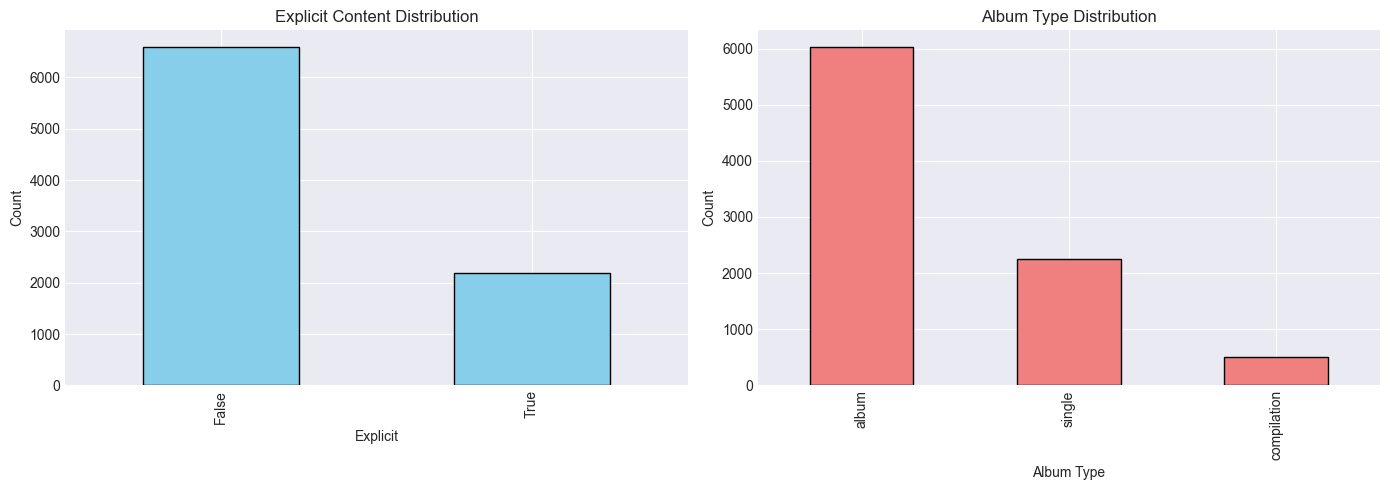

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['explicit'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Explicit Content Distribution')
axes[0].set_xlabel('Explicit')
axes[0].set_ylabel('Count')

df['album_type'].value_counts().plot(kind='bar', ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Album Type Distribution')
axes[1].set_xlabel('Album Type')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
print("Top 10 artists:")
print(df['artist_name'].value_counts().head(10))

print("\nTop 10 artist genres:")
print(df['artist_genres'].value_counts().head(10))


Top 10 artists:
artist_name
Taylor Swift         330
The Weeknd           151
Ariana Grande        101
Lana Del Rey          99
Nirvana               91
Drake                 86
Post Malone           83
The Neighbourhood     77
Lady Gaga             72
Olivia Rodrigo        70
Name: count, dtype: int64

Top 10 artist genres:
artist_genres
[]                    4492
['soundtrack']         346
['pop']                303
['soft pop']           209
['rap']                192
['dark r&b']           111
['k-pop']               93
['grunge', 'rock']      91
['country']             90
['edm']                 82
Name: count, dtype: int64


Tất cả các cột categorical đều có phân bố mất cân bằng: `explicit` (75:25), `album_type` (69:26:5), `artist_name` (top artist chiếm ~4%), `artist_genres` (652 tổ hợp). Phân bố này có thể gây bias trong các mô hình Machine Learning và cần lưu ý khi phân tích các nhóm thiểu số.

### Chất lượng dữ liệu

In [ ]:
for col in categorical_cols:
    missing_pct = df[col].isnull().sum() / len(df) * 100
    print(f"{col}: {missing_pct:.2f}% missing")

explicit: 0.00% missing
album_type: 0.00% missing
artist_name: 0.05% missing
artist_genres: 0.05% missing


Tỷ lệ dữ liệu bị thiếu rất thấp (< 0.1%). Không có sự không nhất quán trong các danh mục vì `explicit` và `album_type` là các giá trị boolean/enum.

## 2.5 Phân tích dữ liệu bị thiếu

In [ ]:
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Percent', ascending=False)

missing_summary[missing_summary['Missing_Count'] > 0]

,Column,Missing_Count,Missing_Percent
year,year,201,2.29
album_release_date,album_release_date,201,2.29
artist_name,artist_name,4,0.05
artist_genres,artist_genres,4,0.05
album_name,album_name,2,0.02
track_name,track_name,2,0.02


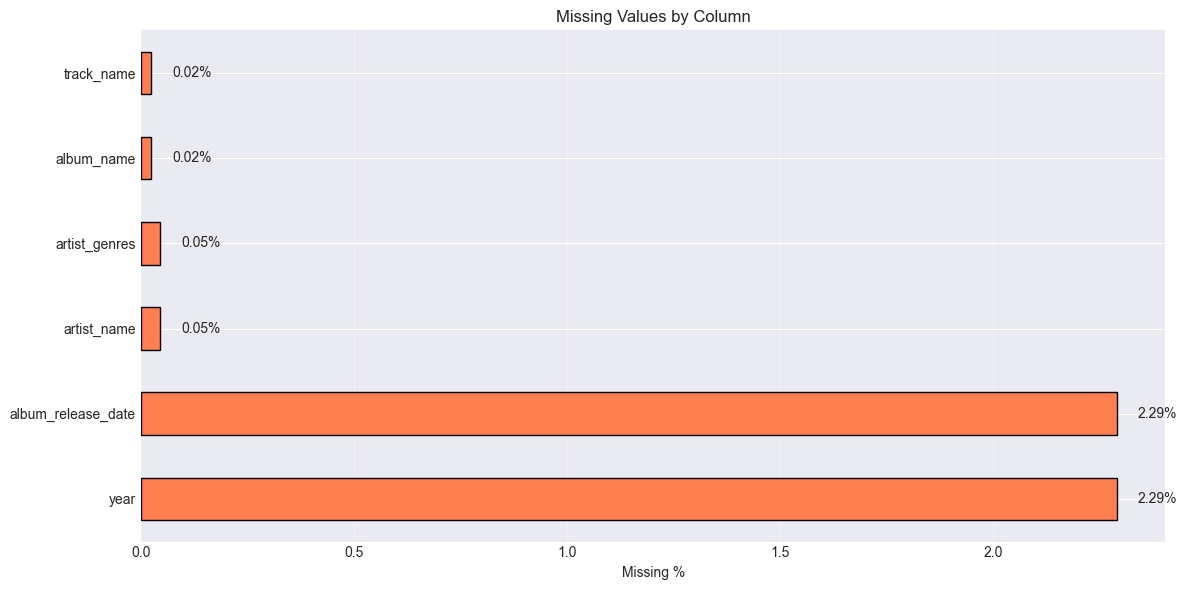

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) > 0:
    missing_pct.plot(kind='barh', ax=ax, color='coral', edgecolor='black')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column')
    ax.grid(alpha=0.3, axis='x')
    
    for i, v in enumerate(missing_pct):
        ax.text(v + 0.05, i, f'{v:.2f}%', va='center')
else:
    ax.text(0.5, 0.5, 'No missing values found', ha='center', va='center', fontsize=14)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

Giá trị bị thiếu (Missing values) chỉ xuất hiện ở:
- `year` (2.29%): Do lỗi phân tích ngày tháng (parse date) từ `album_release_date`
- `artist_name`, `artist_genres` (0.05%): 4 bài hát thiếu thông tin nghệ sĩ

Chiến lược xử lý: loại bỏ những dòng có chứa `NaN` vì tỷ lệ rất thấp.

## 2.6 Mối quan hệ & Tương quan

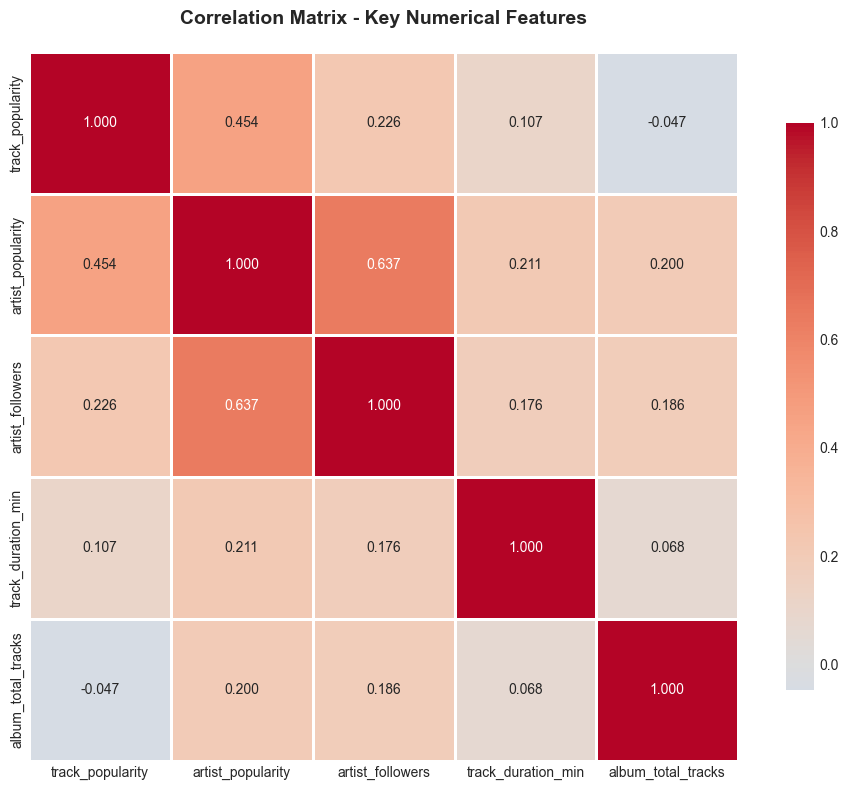

In [ ]:
corr_cols = [
    'track_popularity', 
    'artist_popularity', 
    'artist_followers', 
    'track_duration_min', 
    'album_total_tracks'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Key Numerical Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Tương quan giữa `track_popularity` và `artist_followers` khá yếu (0.226), cho thấy số lượng followers không trực tiếp quyết định độ phổ biến của bài hát. Ngược lại, `artist_popularity` có tương quan mạnh hơn nhiều với `track_popularity` (0.454), chứng tỏ danh tiếng hiện tại của nghệ sĩ quan trọng hơn quy mô cộng đồng người hâm mộ.

In [ ]:
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print("Top 5 strongest correlations:")
for col1, col2, corr in corr_pairs[:5]:
    print(f"{col1} <-> {col2}: {corr:.3f}")

Top 5 strongest correlations:
artist_popularity <-> artist_followers: 0.637
track_popularity <-> artist_popularity: 0.454
track_popularity <-> artist_followers: 0.226
artist_popularity <-> track_duration_min: 0.211
artist_popularity <-> album_total_tracks: 0.200


### Bảng chéo

In [ ]:
pd.crosstab(df['explicit'], df['album_type'], margins=True)

album_type,album,compilation,single,All
explicit,,,,
False,4446,471,1669,6586
True,1576,37,579,2192
All,6022,508,2248,8778


### Thống kê tóm tắt theo nhóm

In [ ]:
df.groupby('album_type')[['track_popularity', 'artist_popularity', 'track_duration_min']].mean()

,track_popularity,artist_popularity,track_duration_min
album_type,,,
album,55.53,74.72,3.64
compilation,40.51,61.76,3.58
single,46.05,58.91,3.13


In [ ]:
df.groupby('explicit')[['track_popularity', 'artist_popularity', 'artist_followers']].mean()

,track_popularity,artist_popularity,artist_followers
explicit,,,
False,50.48,67.98,22093440.16
True,57.51,75.75,31105016.24


## 2.7 Quan sát ban đầu & Insight

### Các quan sát chínhh

1.  Cả `track_popularity` và `artist_popularity` đều có phân bố lệch trái, cho thấy phần lớn các bài hát (tracks) và nghệ sĩ (artists) có độ phổ biến cao (50-80). Có sự tương quan mạnh giữa độ phổ biến của nghệ sĩ và độ phổ biến của bài hát (0.454).

2. `Track duration`: Trung bình 3.5 phút, phân bố khá tập trung quanh giá trị này. Có 4.29% outliers là các bài hát dài bất thường (> 6 phút).

3. 25% bài hát có nội dung nhạy cảm (explicit). Các bài hát explicit có độ phổ biến cao hơn (57.5 so với 50.5) và thường thuộc về nghệ sĩ nổi tiếng hơn.

4. Phần lớn là album (68.6%), đĩa đơn (singles) và tuyển tập (compilations) ít hơn. Bài hát từ albums có độ phổ biến cao nhất (55.5), singles thấp nhất (46.1).

### Các vấn đề về chất lượng dữ liệu

1. 201 bài hát (2.29%) thiếu thông tin năm do lỗi phân tích ngày tháng. Chỉ 4 bài hát (0.05%) thiếu thông tin nghệ sĩ.

2. 521 bài hát có độ phổ biến (popularity) = 0, có thể là bài hát mới chưa được đánh giá hoặc chưa phát hành công khai.

3. Bộ dữ liệu thiên về nghệ sĩ nổi tiếng (Taylor Swift chiếm 330 bài hát, 3.76%). Có thể gây bias khi phân tích xu hướng chung của ngành công nghiệp.

### Các bước tiền xử lý cần thiết

1. Xử lý giá trị bị thiếu: Có thể loại bỏ nếu có `NaN`.

2. Xử lý giá trị ngoại lai: Giữ nguyên vì chúng là các giá trị cực đoan thực tế, không phải lỗi.

3. Mã hóa: One-hot encode cho `explicit` và `album_type`.

### Các mẫu thú vị

1. Nghệ sĩ nổi tiếng có tương quan mạnh với độ phổ biến của bài hát (track popularity).

2. Các bài hát có nội dung nhạy cảm (explicit) có độ phổ biến trung bình cao hơn 7 điểm (57.5 so với 50.5), có thể do đối tượng khán giả khác biệt.

3. Bài hát từ albums có hiệu suất tốt hơn singles.

### Cảnh báo & Hạn chế

1. Bộ dữ liệu tập trung vào các nghệ sĩ hàng đầu (Taylor Swift 3.76%, The Weeknd 1.72%).

2. Không có thể loại cho từng bài hát gây khó khăn cho việc phân tích thể loại.

3. Thiếu thông tin về tempo, key, energy, danceability, các đặc trưng quan trọng để phân tích đặc điểm âm nhạc.